# Thermal sharpening, step by step

### A numpy walk-through of the Data Mining Sharpener (Gao et al., 2012)

This notebook re-implements, in plain `numpy`, the thermal-sharpening
algorithm that pyWaPOR runs in `pywapor/enhancers/dms/pyDMS.py` (the
`DecisionTreeSharpener`). The production code uses GDAL for raster I/O and
scikit-learn for the regressor; here we strip both away so the *ideas* stay
visible, but we keep the two pieces that matter most and rebuild them from
scratch:

* a small **bagged ensemble of regression trees with per-leaf linear
  regression** (same design as the production regressor), and
* averaging temperatures in **radiance space** (`T**4`), as DMS does for land
  surface temperature.

**The problem.** We have a *coarse* image we want to sharpen (e.g. land
surface temperature) and several *fine* feature images (e.g. NDVI, albedo).
We learn how the target relates to the features at the coarse scale, then
apply that relationship at the fine scale.

**The pipeline.**

1. Aggregate the fine features to the coarse grid (block mean) and measure
   within-pixel heterogeneity (block std).
2. Keep only homogeneous coarse pixels as training samples.
3. Fit a regression: `coarse_target ~ f(coarse_features)`.
4. Apply that regression to the *fine* features → a fine first guess.
5. Residual correction: spread the coarse-scale mismatch back over the fine
   guess so that averaging the result reproduces the coarse observation.

> Reference: Gao, F., Kustas, W. P., & Anderson, M. C. (2012). *A Data Mining
> Approach for Sharpening Thermal Satellite Imagery over Land.* Remote
> Sensing, 4(11), 3287-3319. https://doi.org/10.3390/rs4113287

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## Helper functions

These pure-numpy helpers stand in for the GDAL resampling used in the real
code: block aggregation (the coarse sensor averaging), bilinear up-sampling,
and a binomial smoother for the residual field.

In [2]:
def block_mean(arr, factor):
    '''Average each factor x factor block -> coarse grid (2-D or 3-D).'''
    h, w = arr.shape[:2]
    assert h % factor == 0 and w % factor == 0, 'shape must divide by factor'
    if arr.ndim == 2:
        return arr.reshape(h // factor, factor, w // factor, factor).mean((1, 3))
    b = arr.shape[2]
    return arr.reshape(h // factor, factor, w // factor, factor, b).mean((1, 3))


def block_std(arr, factor):
    '''Standard deviation within each factor x factor block (2-D or 3-D).'''
    h, w = arr.shape[:2]
    if arr.ndim == 2:
        return arr.reshape(h // factor, factor, w // factor, factor).std((1, 3))
    b = arr.shape[2]
    return arr.reshape(h // factor, factor, w // factor, factor, b).std((1, 3))


def bilinear_upsample(coarse, out_shape):
    '''Bilinearly resample a coarse 2-D array up to out_shape (pure numpy).'''
    in_h, in_w = coarse.shape
    out_h, out_w = out_shape
    col_src = (np.arange(out_w) + 0.5) * in_w / out_w - 0.5
    row_src = (np.arange(out_h) + 0.5) * in_h / out_h - 0.5
    tmp = np.empty((in_h, out_w))
    xcols = np.arange(in_w)
    for i in range(in_h):
        tmp[i] = np.interp(col_src, xcols, coarse[i])
    out = np.empty((out_h, out_w))
    yrows = np.arange(in_h)
    for j in range(out_w):
        out[:, j] = np.interp(row_src, yrows, tmp[:, j])
    return out


def binomial_smooth(arr):
    '''3x3 binomial (1-2-1)x(1-2-1) smoothing, edge-padded.'''
    k = np.array([1.0, 2.0, 1.0]); k = k / k.sum()
    p = np.pad(arr, 1, mode='edge')
    tmp = k[0] * p[:, :-2] + k[1] * p[:, 1:-1] + k[2] * p[:, 2:]
    return k[0] * tmp[:-2, :] + k[1] * tmp[1:-1, :] + k[2] * tmp[2:, :]

## Dummy data

We synthesize a fine-resolution *truth* temperature field that depends on the
fine features in three deliberately different ways, then average it down to
make the coarse observation. Because we keep the truth, we can score how close
the sharpened result gets.

The truth contains:

* a **linear-in-features** part — any regressor can learn it,
* a **non-linear-in-features** part (`sin` of NDVI) — a single linear fit
  cannot capture this but the tree ensemble can; this is *why* DMS uses trees,
* a **feature-independent** part — only the residual-correction step (5) can
  recover it.

The coarse pixel is the 4th-root of the mean of `T**4` (radiance averaging),
matching how a thermal sensor integrates energy.

In [28]:
def make_dummy_inputs(fine_shape=(120, 120), factor=10, seed=0):
    rng = np.random.default_rng(seed)
    H, W = fine_shape
    yy, xx = np.mgrid[0:H, 0:W] / max(H, W)

    ndvi = 0.5 + 0.4 * np.sin(6 * xx) * np.cos(5 * yy)
    ndvi = np.clip(ndvi + 0.15 * rng.standard_normal((H, W)), 0, 1)

    albedo = 0.3 - 0.2 * ndvi + 0.1 * np.cos(10 * xx + 3 * yy)
    albedo = np.clip(albedo + 0.05 * rng.standard_normal((H, W)), 0.05, 0.6)

    builtup = (np.sin(3 * xx) > 0.4).astype(float)
    builtup += 0.05 * rng.standard_normal((H, W))

    features = np.stack([ndvi, albedo, builtup], axis=-1)

    truth = (305.0
             - 18.0 * ndvi
             + 12.0 * albedo
             + 8.0 * builtup
             + 10.0 * np.sin(8.0 * ndvi)          # non-linear in a feature
             + 4.0 * np.sin(2.5 * xx + 1.5 * yy)) # unexplained structure
    truth += 0.3 * rng.standard_normal((H, W))    # sensor-ish noise

    # coarse sensor averages in radiance space (T**4)
    lowres_target = block_mean(truth ** 4, factor) ** 0.25
    return features, lowres_target, truth


factor = 20
features, lowres_target, truth = make_dummy_inputs(factor=factor)
H, W, B = features.shape
h, w = lowres_target.shape
print(f'fine features {features.shape}, coarse target {lowres_target.shape}')

fine features (120, 120, 3), coarse target (6, 6)


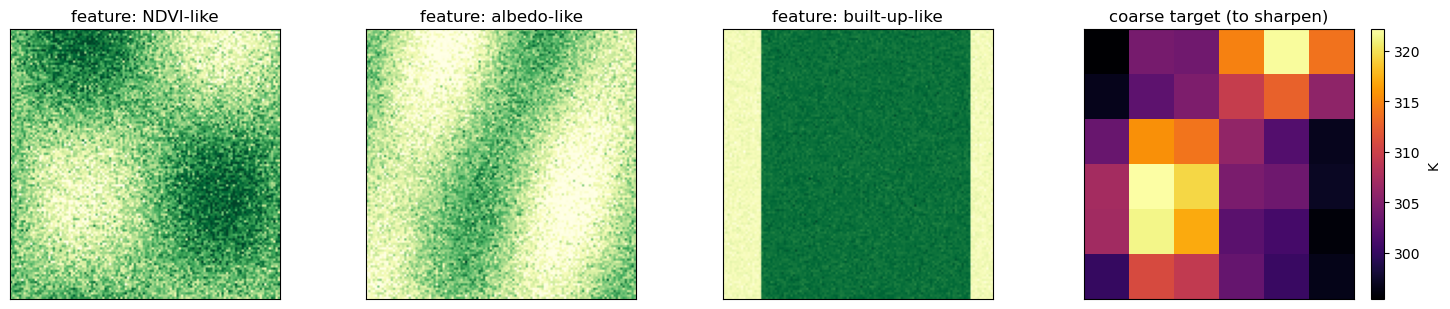

In [29]:
fig, axs = plt.subplots(1, 4, figsize=(15, 3.2))
names = ['NDVI-like', 'albedo-like', 'built-up-like']
for k in range(3):
    axs[k].imshow(features[..., k], cmap='YlGn'); axs[k].set_title('feature: ' + names[k])
im = axs[3].imshow(lowres_target, cmap='inferno'); axs[3].set_title('coarse target (to sharpen)')
fig.colorbar(im, ax=axs[3], fraction=0.046, label='K')
for ax in axs: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Step 1 — aggregate the fine features to the coarse grid

To learn a relationship at the coarse scale, the features must live on the
coarse grid too. We take the block **mean** (to line them up with the coarse
target) and keep the block **std** as a measure of how mixed each coarse pixel
is internally.

In [30]:
feat_coarse_mean = block_mean(features, factor)   # (h, w, B)
feat_coarse_std  = block_std(features, factor)    # (h, w, B)
print('coarse feature stack:', feat_coarse_mean.shape)

coarse feature stack: (6, 6, 3)


## Step 2 — select homogeneous training pixels

A coarse pixel that is internally very mixed is a poor teacher: we don't know
how its single coarse target value maps onto the varied fine features inside
it. The **coefficient of variation** (std / mean), averaged over features,
measures that mixing — low CV means homogeneous. Following pyDMS we keep
pixels below the 80th percentile of CV, and weight each kept sample by the
inverse of its heterogeneity (more homogeneous → more trustworthy).

CV threshold (p80) = 0.621
29 / 36 coarse pixels used for training


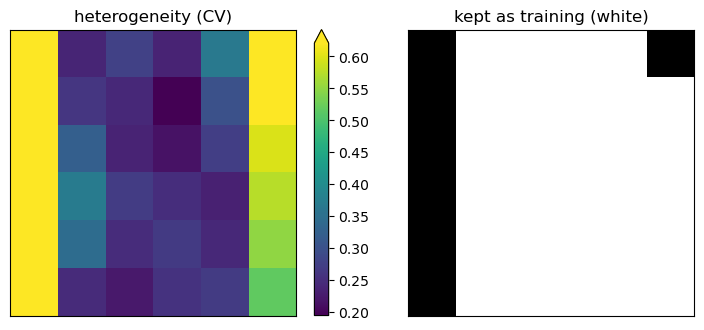

In [31]:
eps = 1e-6
cv = np.mean(feat_coarse_std / (np.abs(feat_coarse_mean) + eps), axis=-1)  # (h, w)
cv_threshold = np.percentile(cv, 80)
homogeneous = cv <= cv_threshold
sample_weight = 1.0 / (cv[homogeneous] + eps)
print(f'CV threshold (p80) = {cv_threshold:.3f}')
print(f'{homogeneous.sum()} / {h * w} coarse pixels used for training')

fig, axs = plt.subplots(1, 2, figsize=(8, 3.4))
im = axs[0].imshow(cv, cmap='viridis', vmax=cv_threshold); axs[0].set_title('heterogeneity (CV)')
fig.colorbar(im, ax=axs[0], fraction=0.046, extend="max")
axs[1].imshow(homogeneous, cmap='Greys_r'); axs[1].set_title('kept as training (white)')
for ax in axs: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Step 3 — fit the regression on the coarse grid

We learn `target ~ features` using the homogeneous samples. Two regressors:

* **linear** — one weighted multivariate least-squares fit (easy to read).
* **tree** — a bagged ensemble of regression trees, each leaf carrying its own
  linear regression with clamped extrapolation. This is the same design as the
  production `DecisionTreeRegressorWithLinearLeafRegression` + `BaggingRegressor`,
  written here from scratch in numpy.

In [32]:
def _weighted_linear_fit(X, y, w):
    '''Weighted least squares with intercept. Returns (coef[B], intercept).'''
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    sw = np.sqrt(w)[:, None]
    beta, *_ = np.linalg.lstsq(A * sw, y * sw[:, 0], rcond=None)
    return beta[:-1], beta[-1]


def _weighted_sse(y, w):
    if y.size == 0:
        return 0.0
    mu = np.average(y, weights=w)
    return float(np.sum(w * (y - mu) ** 2))


class RegressionTree:
    '''Minimal CART regression tree with optional per-leaf linear regression.'''
    def __init__(self, max_depth=4, min_samples_leaf=10,
                 per_leaf_linear=True, extrapolation_ratio=0.25):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.per_leaf_linear = per_leaf_linear
        self.extrapolation_ratio = extrapolation_ratio
        self.root = None

    def fit(self, X, y, w):
        self.root = self._build(X, y, w, 0)
        return self

    def _build(self, X, y, w, depth):
        if (depth >= self.max_depth or y.size < 2 * self.min_samples_leaf
                or np.ptp(y) < 1e-9):
            return self._make_leaf(X, y, w)
        feature, threshold = self._best_split(X, y, w)
        if feature is None:
            return self._make_leaf(X, y, w)
        left = X[:, feature] <= threshold
        return {'leaf': False, 'feature': feature, 'threshold': threshold,
                'left': self._build(X[left], y[left], w[left], depth + 1),
                'right': self._build(X[~left], y[~left], w[~left], depth + 1)}

    def _best_split(self, X, y, w):
        # exhaustive O(features * n^2) search -- clear, fast enough for DMS.
        n, n_features = X.shape
        parent = _weighted_sse(y, w)
        best_sse, best = np.inf, (None, None)
        m = self.min_samples_leaf
        for f in range(n_features):
            order = np.argsort(X[:, f], kind='mergesort')
            sv, sy, sw = X[order, f], y[order], w[order]
            for i in range(m, n - m + 1):
                if sv[i] == sv[i - 1]:
                    continue
                sse = _weighted_sse(sy[:i], sw[:i]) + _weighted_sse(sy[i:], sw[i:])
                if sse < best_sse:
                    best_sse, best = sse, (f, 0.5 * (sv[i] + sv[i - 1]))
        return best if best_sse < parent - 1e-12 else (None, None)

    def _make_leaf(self, X, y, w):
        node = {'leaf': True, 'value': float(np.average(y, weights=w))}
        if self.per_leaf_linear and y.size > X.shape[1] + 1 and np.ptp(y) > 0:
            coef, intercept = _weighted_linear_fit(X, y, w)
            span = self.extrapolation_ratio * (y.max() - y.min())
            node['linear'] = (coef, intercept, y.min() - span, y.max() + span)
        return node

    def predict(self, X):
        out = np.empty(X.shape[0])
        self._predict(self.root, X, np.arange(X.shape[0]), out)
        return out

    def _predict(self, node, X, idx, out):
        if idx.size == 0:
            return
        if node['leaf']:
            if 'linear' in node:
                coef, intercept, lo, hi = node['linear']
                out[idx] = np.clip(X[idx] @ coef + intercept, lo, hi)
            else:
                out[idx] = node['value']
            return
        left = X[idx, node['feature']] <= node['threshold']
        self._predict(node['left'], X, idx[left], out)
        self._predict(node['right'], X, idx[~left], out)


def fit_bagged_trees(X, y, w, n_trees=10, seed=0):
    '''Bagging: each tree trained on a bootstrap resample; predict = average.'''
    rng = np.random.default_rng(seed)
    n = y.size
    trees = [RegressionTree().fit(*(lambda b: (X[b], y[b], w[b]))(rng.integers(0, n, n)))
             for _ in range(n_trees)]
    return lambda Xf: np.mean([t.predict(Xf) for t in trees], axis=0)

In [33]:
X_train = feat_coarse_mean[homogeneous]   # (n, B)
y_train = lowres_target[homogeneous]      # (n,)

# linear
coef, intercept = _weighted_linear_fit(X_train, y_train, sample_weight)
predict_linear = lambda Xf: Xf @ coef + intercept
print('linear intercept =', round(intercept, 2), ' coefficients =', np.round(coef, 2))

# tree ensemble
predict_tree = fit_bagged_trees(X_train, y_train, sample_weight, n_trees=10)
print('trained a bagged ensemble of 10 trees (per-leaf linear regression)')

linear intercept = 309.29  coefficients = [-30.77   3.66  14.61]
trained a bagged ensemble of 10 trees (per-leaf linear regression)


## Step 4 — apply the regression to the *fine* features

The features exist at fine resolution, so applying the learned relationship to
them yields a fine-resolution prediction: the sharpened **first guess**.

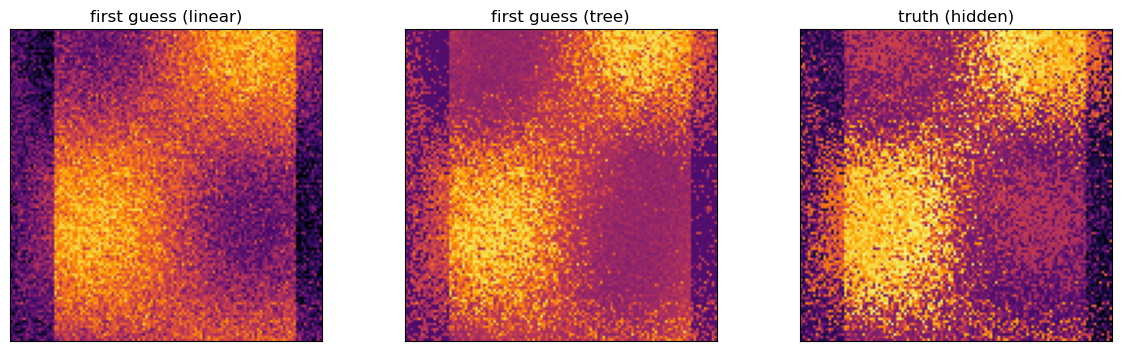

In [34]:
fine_flat = features.reshape(-1, B)
first_guess_lin  = predict_linear(fine_flat).reshape(H, W)
first_guess_tree = predict_tree(fine_flat).reshape(H, W)

vmin, vmax = truth.min(), truth.max()
tkw = dict(vmin=vmin, vmax=vmax, cmap='inferno')
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
axs[0].imshow(first_guess_lin, **tkw);  axs[0].set_title('first guess (linear)')
axs[1].imshow(first_guess_tree, **tkw); axs[1].set_title('first guess (tree)')
axs[2].imshow(truth, **tkw);            axs[2].set_title('truth (hidden)')
for ax in axs: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## Step 5 — residual correction (and the `T**4` trick)

The regression captures the feature-driven signal but not what the features
cannot explain. We enforce consistency: average the fine guess back to the
coarse grid, compare with the observed coarse image, smooth that residual,
up-sample it, and add it back. The corrected result, re-aggregated, reproduces
the coarse observation.

For **temperature** we do the aggregation and differencing in **radiance**
space (`T**4`) and apply the correction there, then take the 4th root —
mirroring pyDMS `corrected = (residual_HR + scene_HR**4)**0.25`.

In [35]:
def residual_correct(first_guess, lowres_target, factor, temperature=True):
    H, W = first_guess.shape
    if temperature:
        guess_coarse = block_mean(first_guess ** 4, factor)      # radiance
        residual_coarse = lowres_target ** 4 - guess_coarse      # radiance
        residual_fine = bilinear_upsample(binomial_smooth(residual_coarse), (H, W))
        sharpened = np.maximum(first_guess ** 4 + residual_fine, 1.0) ** 0.25
        res_T = (residual_coarse + 273.15 ** 4) ** 0.25 - 273.15  # back to K
    else:
        guess_coarse = block_mean(first_guess, factor)
        residual_coarse = lowres_target - guess_coarse
        residual_fine = bilinear_upsample(binomial_smooth(residual_coarse), (H, W))
        sharpened = first_guess + residual_fine
        res_T = residual_coarse
    bias = np.nanmean(res_T); rmsd = np.sqrt(np.nanmean(res_T ** 2))
    return sharpened, residual_fine, bias, rmsd


sharp_lin,  resf_lin,  b_l, r_l = residual_correct(first_guess_lin,  lowres_target, factor)
sharp_tree, resf_tree, b_t, r_t = residual_correct(first_guess_tree, lowres_target, factor)
print(f'linear: coarse residual bias = {b_l:+.3f} K, RMSD = {r_l:.3f} K')
print(f'tree:   coarse residual bias = {b_t:+.3f} K, RMSD = {r_t:.3f} K')

linear: coarse residual bias = +0.844 K, RMSD = 4.315 K
tree:   coarse residual bias = -1.854 K, RMSD = 3.503 K


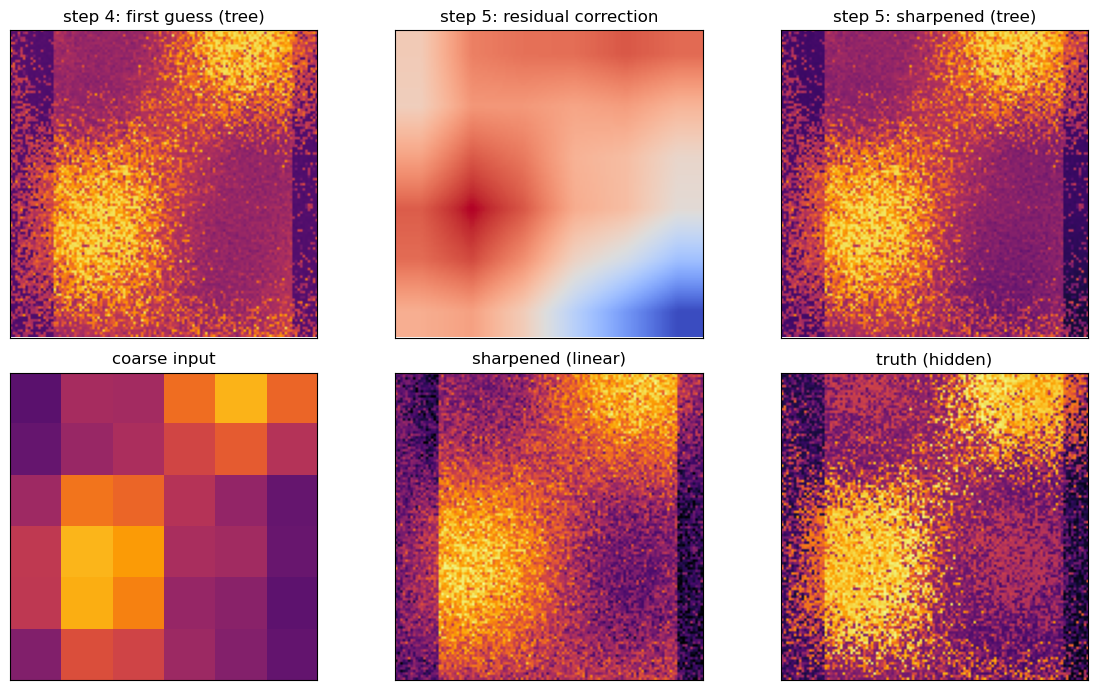

In [36]:
fig, axs = plt.subplots(2, 3, figsize=(12, 7))
axs[0, 0].imshow(first_guess_tree, **tkw); axs[0, 0].set_title('step 4: first guess (tree)')
axs[0, 1].imshow(resf_tree, cmap='coolwarm'); axs[0, 1].set_title('step 5: residual correction')
axs[0, 2].imshow(sharp_tree, **tkw); axs[0, 2].set_title('step 5: sharpened (tree)')
axs[1, 0].imshow(lowres_target, **tkw); axs[1, 0].set_title('coarse input')
axs[1, 1].imshow(sharp_lin, **tkw); axs[1, 1].set_title('sharpened (linear)')
axs[1, 2].imshow(truth, **tkw); axs[1, 2].set_title('truth (hidden)')
for ax in axs.ravel(): ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## How good is it?

We compare against the hidden truth (RMSE, lower is better). A naive bilinear
up-sample of the coarse image — no sharpening at all — is the baseline.

In [26]:
def rmse(p): return float(np.sqrt(np.mean((p - truth) ** 2)))

naive = bilinear_upsample(lowres_target, truth.shape)
rows = [
    ('naive bilinear upsample',      rmse(naive)),
    ('linear: first guess (step 4)', rmse(first_guess_lin)),
    ('linear: sharpened (step 5)',   rmse(sharp_lin)),
    ('tree:   first guess (step 4)', rmse(first_guess_tree)),
    ('tree:   sharpened (step 5)',   rmse(sharp_tree)),
]
print(f'{"method":<32s} RMSE vs truth (K)')
print('-' * 50)
for name, val in rows:
    print(f'{name:<32s} {val:6.3f}')

method                           RMSE vs truth (K)
--------------------------------------------------
naive bilinear upsample           7.561
linear: first guess (step 4)      7.017
linear: sharpened (step 5)        6.402
tree:   first guess (step 4)      5.166
tree:   sharpened (step 5)        3.952


## Takeaways

* **Sharpening beats naive up-sampling** for both regressors — the fine
  features carry real sub-pixel information.
* **The tree ensemble beats the single linear fit** here, because the truth is
  partly *non-linear* in the features. On a purely linear truth the linear fit
  would win; trees earn their keep when the relationship is non-linear, which
  is the usual case for real land surfaces — hence pyDMS uses them.
* **Step 5 always helps**, because it injects the feature-independent
  structure that no regression on the features could ever reproduce, while
  guaranteeing the result stays consistent with the coarse observation.

To go from this to production (`pyDMS.py`): swap the numpy I/O for GDAL
(reprojection, no-data handling, georeferencing), and swap this hand-rolled
tree for scikit-learn's `BaggingRegressor`. The algorithm is the same.